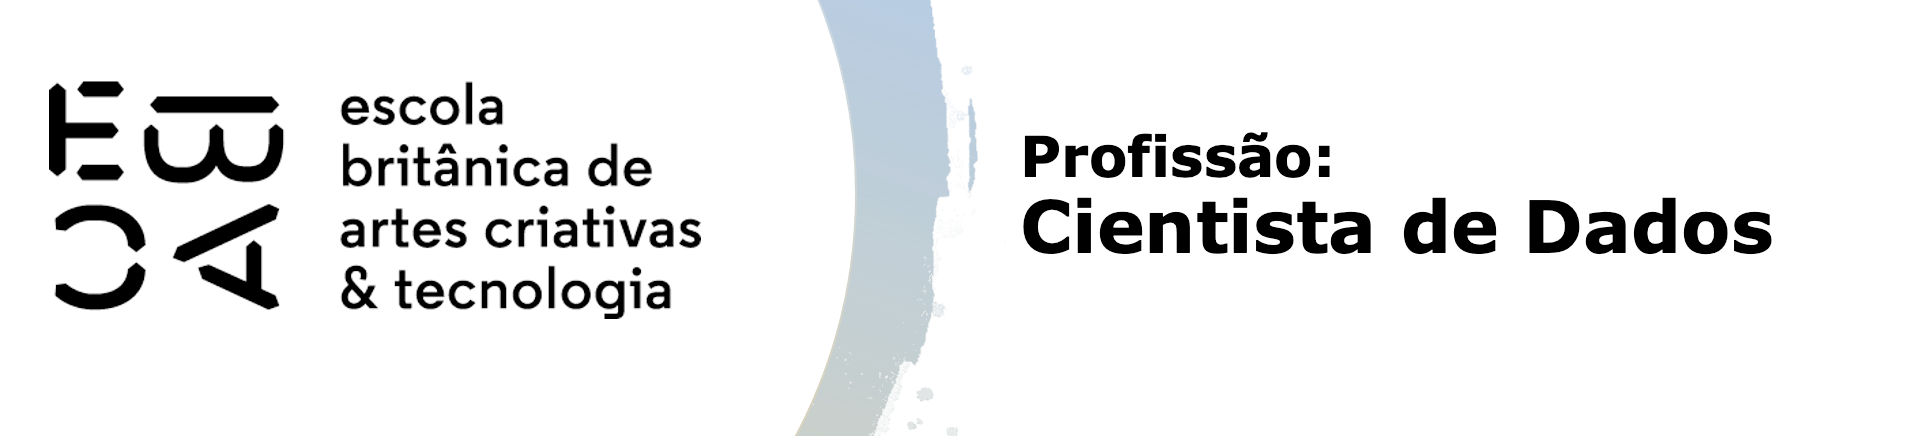

# Tarefa

Com base na tarefa realizada no módulo anterior, vamos fazer um diagnóstico do modelo.

Carregue a base ```previsao_de_renda2.csv```. Separe em uma base de treino e uma base de teste.

Vamos resgatar a melhor versão do modelo de previsão de renda que você fez para esta base. 

- Substitua missings pela média
- Rode novamente o modelo na base de treino (ou desenvolva-o caso não tenha o registro guardado). 

Este modelo deve prever a variável ```renda``` com base nas demais variáveis exceto ```data_ref``` e ```index```. Já vimos que a variável renda é melhor modelada com a transformação ```log()```, não se esqueça disso.

In [75]:
# Importa a biblioteca pandas para manipulação de dados em DataFrames
import pandas as pd

# Importa a biblioteca numpy para operações numéricas
import numpy as np

# Importa a função para modelos lineares do statsmodels usando fórmulas
import statsmodels.formula.api as smf

# Importa seaborn para visualização de dados estatísticos
import seaborn as sns

# Importa o módulo pyplot do matplotlib para criação de gráficos
import matplotlib.pyplot as plt

# Importa a API principal do statsmodels para análise estatística
import statsmodels.api as sm

# Importa função para dividir os dados em treino e teste
from sklearn.model_selection import train_test_split

# Importa a função para cálculo do VIF (Variance Inflation Factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

import unicodedata

from statsmodels.graphics.regressionplots import influence_plot

from sklearn.metrics import mean_squared_error



In [76]:
# Função para criar dataframe VIF e realizar a filtragem de variáveis que possuírem um valor acima do estipulado nos parâmetros
def vif_filter(X, limite=10):
    """
    Filtra variáveis com alto fator de inflação de variância (VIF) de um DataFrame.

    Parâmetros:
    X (pd.DataFrame): DataFrame contendo apenas variáveis numéricas independentes.
    limite (float): Valor limite de VIF para remoção de variáveis (padrão=10).

    Retorna:
    X_filtrado (pd.DataFrame): DataFrame com variáveis remanescentes após filtragem.
    removed_features (list): Lista de tuplas (variável, VIF) removidas.
    remaining_vif (pd.DataFrame): DataFrame com VIF das variáveis remanescentes.
    """
    X_filtrado = X.copy()  # Cria uma cópia do DataFrame original
    removed_features = []  # Lista para armazenar variáveis removidas
    vif_scores = {}        # Dicionário para armazenar os VIFs

    while True:
        # Adiciona constante para cálculo do VIF
        X_with_const = add_constant(X_filtrado)

        # Calcula o VIF para cada variável (incluindo a constante)
        vif_data = pd.DataFrame()
        vif_data["feature"] = X_with_const.columns
        vif_data["VIF"] = [vif(X_with_const.values, i)
                           for i in range(X_with_const.shape[1])]

        # Remove a constante da análise
        vif_data = vif_data[vif_data['feature'] != 'const']

        # Salva os VIFs calculados
        for _, row in vif_data.iterrows():
            vif_scores[row['feature']] = row['VIF']

        # Verifica o maior VIF
        max_vif = vif_data['VIF'].max()
        if max_vif <= limite:
            break  # Sai do loop se todos os VIFs estiverem abaixo do limite

        # Remove a variável com maior VIF
        feature_to_remove = vif_data.loc[vif_data['VIF'].idxmax(), 'feature']
        removed_features.append((feature_to_remove, max_vif))
        X_filtrado = X_filtrado.drop(columns=[feature_to_remove])

        # Se todas as variáveis forem removidas, lança erro
        if X_filtrado.shape[1] == 0:
            raise ValueError("Todas as variáveis foram removidas - limite pode estar muito baixo")

    # Monta DataFrame final com VIF das variáveis remanescentes
    remaining_vif = vif_data[vif_data['feature'].isin(X_filtrado.columns)]
    remaining_vif = remaining_vif.sort_values('VIF', ascending=False)

    return X_filtrado, removed_features, remaining_vif



# Função para remover caracteres especiais e adicionar "_" nos espaços
def padronizar_nome(var):
    """
    Remove caracteres especiais de uma string e substitui espaços por underline.

    Parâmetros:
    var (str): Nome da variável a ser padronizado.

    Retorna:
    str: Nome padronizado, sem acentos e com espaços substituídos por "_".
    """
    # Normaliza a string para remover acentos e caracteres especiais
    var = unicodedata.normalize('NFKD', var).encode('ASCII', 'ignore').decode('ASCII')
    return var.replace(' ', '_')  # Substitui espaços por underline



def esp_vs_obs(data, res, X, y_pred, y_true, transformar=False, amostragem=False, tamanho=1000):
    # Obtém as previsões do modelo OLS
    pred_ols = res.get_prediction()
    pred_summary = pred_ols.summary_frame()

    # Extrai intervalos de confiança para observações e médias
    iv_l = pred_summary['obs_ci_lower']
    iv_u = pred_summary['obs_ci_upper']
    m_l = pred_summary['mean_ci_lower']
    m_u = pred_summary['mean_ci_upper']

    # Se amostragem for True, utiliza apenas as primeiras 'tamanho' linhas
    if amostragem:
        data = data.head(tamanho)
        y_pred = y_pred.head(tamanho)
        iv_l = iv_l.head(tamanho)
        iv_u = iv_u.head(tamanho)
        m_l = m_l.head(tamanho)
        m_u = m_u.head(tamanho)

    # Cria uma cópia do dataframe ordenado pelo eixo X
    df_plot = data.copy()
    df_plot["y_pred"] = y_pred
    df_plot["iv_l"] = iv_l
    df_plot["iv_u"] = iv_u
    df_plot["m_l"] = m_l
    df_plot["m_u"] = m_u
    # Se transformar=True, aplica log na variável resposta real
    df_plot["y_real"] = np.log(data[y_true]) if transformar else data[y_true]
    df_plot = df_plot.sort_values(by=X)

    fig, ax = plt.subplots(figsize=(8, 6))

    # Scatter dos pontos observados
    ax.plot(df_plot[X], df_plot["y_pred"], 'o', label="Dados observados", alpha=0.5)

    # Linhas conectando em ordem
    ax.plot(df_plot[X], df_plot["y_real"], 'b-', label='Média da simulação (log)' if transformar else 'Média da simulação')
    ax.plot(df_plot[X], df_plot["y_pred"], 'r--', label='Estimativa OLS')
    ax.plot(df_plot[X], df_plot["iv_u"], 'r--', label='Banda de confiança para y')
    ax.plot(df_plot[X], df_plot["iv_l"], 'r--')
    ax.plot(df_plot[X], df_plot["m_u"], 'g:', label='Banda de confiança para média')
    ax.plot(df_plot[X], df_plot["m_l"], 'g:')

    ax.set_xlabel(X)
    ax.set_ylabel(y_true)
    ax.set_title("Expectativa vs Observado")
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()
    
def stepwise_selection(
    X, y, initial_list=[], threshold_in=0.01, threshold_out=0.05, verbose=True
):
    """Perform a forward-backward feature selection
    based on p-value from statsmodels.api.OLS
    Arguments:
        X - pandas.DataFrame with candidate features
        y - list-like with the target
        initial_list - list of features to start with (column names of X)
        threshold_in - include a feature if its p-value < threshold_in
        threshold_out - exclude a feature if its p-value > threshold_out
        verbose - whether to print the sequence of inclusions and exclusions
    Returns: list of selected features
    Always set threshold_in < threshold_out to avoid infinite looping.
    See https://en.wikipedia.org/wiki/Stepwise_regression for the details
    """
    included = list(initial_list)
    while True:
        changed = False
        # forward step
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(
                y, sm.add_constant(pd.DataFrame(X[included + [new_column]]))
            ).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()  # Use idxmin() em vez de argmin() para garantir o nome da coluna
            included.append(best_feature)
            changed = True
            if verbose:
                print("Add  {:30} with p-value {:.6}".format(best_feature, best_pval))

        # backward step
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        # use all coefs except intercept
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max()  # null if pvalues is empty
        if worst_pval > threshold_out:
            changed = True
            worst_feature = pvalues.idxmax()  # Use idxmax() em vez de argmax() para garantir o nome da coluna
            included.remove(worst_feature)
            if verbose:
                print("Drop {:30} with p-value {:.6}".format(worst_feature, worst_pval))
        if not changed:
            break
    return included


In [77]:
previsao_renda = pd.read_csv('./Dataset/previsao_de_renda_II.csv')  # Lê o arquivo CSV com os dados e armazena no DataFrame
previsao_renda.loc[previsao_renda['tempo_emprego'].isna(), 'tempo_emprego'] = previsao_renda.tempo_emprego.mean()  # Substitui valores ausentes em 'tempo_emprego' pela média da coluna

## Verifique as suposições do modelo

Faça uma análise para avaliar as suposições básicas:

- Os resíduos desse modelo possuem distribuição Normal (ou algo próximo)?
- Verifique a independência dos resíduos
    - Faça um gráfico dos resíduos versus os valores preditos
    - Avalie se há padrões dos resíduos versus cada uma das variáveis do modelo
    - Avalie se o valor médio dos resíduos aparenta ter relação com o mês de referência
- Avalie se a variância da variável resposta parece ser conforme os valores previstos.

Você considera que as suposições estão atendidas? Há algum impacto em eventuais desvios?

In [78]:
# Obtém a lista de todas as colunas do DataFrame df
variaveis = previsao_renda.columns.to_list()

# Remove as colunas 'data_ref' e 'index' da lista de variáveis, pois não serão usadas nas análises
variaveis = [x for x in variaveis if x not in ['data_ref', 'index']]

# Define a variável dependente (target) como a nova coluna 'log_renda'
y = previsao_renda['renda']

# Define as variáveis independentes removendo as colunas 'renda' e 'log_renda'
X = previsao_renda[variaveis].drop(columns=['renda'])

# Junta as variáveis independentes e dependente para formar o dataframe de treino
df_treino = X_train.join(y_train)

# Seleciona uma amostra de 30.000 linhas do conjunto de treino para análise de resíduos
df_resid_check = df_treino.sample(30000, random_state=100).reset_index(drop=True)

<Axes: ylabel='renda'>

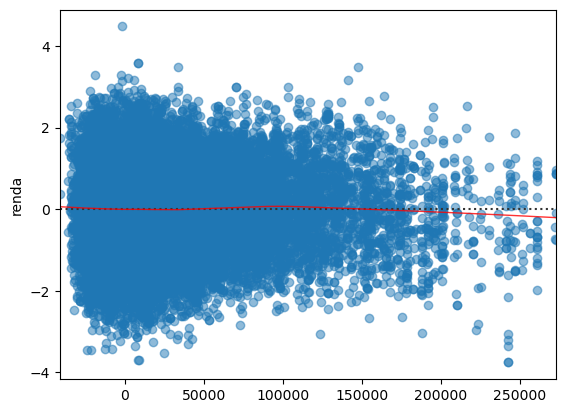

In [79]:
# Seleciona as variáveis independentes, excluindo 'renda', 'index' e 'data_ref'
variaveis_independentes = [var for var in previsao_renda.columns.to_list() if var not in ['renda', 'index', 'data_ref']]

# Monta a fórmula para o modelo de regressão linear
formula = 'renda ~' + '+'.join(variaveis_independentes)

# Ajusta o modelo de regressão linear usando o DataFrame de verificação de resíduos
modelo = smf.ols(formula, data=df_resid_check).fit()

# Plota o gráfico dos resíduos (diferença entre valores observados e previstos) em relação aos valores previstos
sns.residplot(
    x=modelo.predict(df_resid_check[variaveis_independentes]),  # valores previstos pelo modelo
    y=np.log(df_resid_check['renda'] + 1),                      # log da renda observada
    data=df_resid_check,
    lowess=True,                                                # suavização local
    scatter_kws={"alpha": 0.5},                                 # transparência dos pontos
    line_kws={"color": "red", "lw": 1, "alpha": 0.8},           # estilo da linha de tendência
)

In [80]:
# Definir pontos de corte para testar
C1_values = np.linspace(start=previsao_renda['tempo_emprego'].min(),
                       stop=previsao_renda['tempo_emprego'].max(),
                       num=5)  # Reduzindo para 5 pontos para cada variável

C2_values = np.linspace(start=previsao_renda['qtd_filhos'].min(),
                       stop=previsao_renda['qtd_filhos'].max(),
                       num=5)

C3_values = np.linspace(start=previsao_renda['idade'].min(),
                       stop=previsao_renda['idade'].max(),
                       num=5)

# Lista para armazenar resultados
resultados = []

# Testar combinações de pontos de corte
for c1 in C1_values:
    # Criar segmentos para tempo_emprego
    df_resid_check['X1_1'] = np.where(df_resid_check['tempo_emprego'] <= c1, 
                                     df_resid_check['tempo_emprego'], c1)
    df_resid_check['X1_2'] = np.where(df_resid_check['tempo_emprego'] > c1, 
                                     df_resid_check['tempo_emprego'] - c1, 0)
    
    for c2 in C2_values:
        # Criar segmentos para qtd_filhos
        df_resid_check['X2_1'] = np.where(df_resid_check['qtd_filhos'] <= c2, 
                                         df_resid_check['qtd_filhos'], c2)
        df_resid_check['X2_2'] = np.where(df_resid_check['qtd_filhos'] > c2, 
                                         df_resid_check['qtd_filhos'] - c2, 0)
        
        for c3 in C3_values:
            # Criar segmentos para idade
            df_resid_check['X3_1'] = np.where(df_resid_check['idade'] <= c3, 
                                            df_resid_check['idade'], c3)
            df_resid_check['X3_2'] = np.where(df_resid_check['idade'] > c3, 
                                            df_resid_check['idade'] - c3, 0)
            
            # Ajustar modelo
            formula = 'I(np.log(renda+1)) ~ I(np.log(X1_1 + 2)) + I(np.log(X1_2 + 2)) + X2_1 + X2_2 + I(np.log(X3_1 + 2)) + I(np.log(X3_2 + 2))'
            try:
                modelo = smf.ols(formula, data=df_resid_check).fit()
                
                # Armazenar resultados
                resultados.append({
                    'corte_tempo_emprego': c1,
                    'corte_qtd_filhos': c2,
                    'corte_idade': c3,
                    'R2': modelo.rsquared,
                    'AIC': modelo.aic,
                    'BIC': modelo.bic
                })
            except:
                continue

# Converter para DataFrame
df_resultados = pd.DataFrame(resultados)

# Mostrar melhores combinações
df_resultados.sort_values('R2', ascending=False).head(10)

,corte_tempo_emprego,corte_qtd_filhos,corte_idade,R2,AIC,BIC
33,10.815068,3.5,56.5,0.370160,86117.011495,86175.174164
38,10.815068,7.0,56.5,0.370153,86117.331490,86175.494159
43,10.815068,10.5,56.5,0.370153,86117.331490,86175.494159
28,10.815068,0.0,56.5,0.370153,86115.355633,86165.209349
48,10.815068,14.0,56.5,0.370153,86115.355633,86165.209349
32,10.815068,3.5,45.0,0.370121,86118.873933,86177.036601
37,10.815068,7.0,45.0,0.370106,86119.581530,86177.744199
42,10.815068,10.5,45.0,0.370106,86119.581530,86177.744199
47,10.815068,14.0,45.0,0.370106,86117.587429,86167.441145
27,10.815068,0.0,45.0,0.370106,86117.587429,86167.441145


In [81]:
C1 = 10.815068
C2 =  3.5
C3 = 45


### CRIANDO DOIS SEGMENTOS PARA A VARIÁVEL TEMPO_EMPREGO
# Cria a variável segmentada X1_1: igual a X1 se X1 <= C1, senão igual a C1
df_resid_check['X1_1'] = (df_resid_check['tempo_emprego'] <= C1) * df_resid_check['tempo_emprego'] + (df_resid_check['tempo_emprego'] > C1) * C1

# Cria a variável segmentada X1_2: igual a X1 - C1 se X1 > C1, senão zero
df_resid_check['X1_2'] = (df_resid_check['tempo_emprego'] > C1) * (df_resid_check['tempo_emprego'] - C1)


### CRIANDO DOIS SEGMENTOS PARA QTD_FILHOS
# Cria a variável segmentada X2_1: igual a qtd_filhos se qtd_filhos <= C2, senão igual a C2
df_resid_check['X2_1'] = (df_resid_check['qtd_filhos'] <= C2) * df_resid_check['qtd_filhos'] + (df_resid_check['qtd_filhos'] > C2) * C2

# Cria a variável segmentada X1_2: igual a qtd_filhos - C2 se X1 > C2, senão zero
df_resid_check['X2_2'] = (df_resid_check['qtd_filhos'] > C2) * (df_resid_check['qtd_filhos'] - C2)


### CRIANDO DOIS SEGMENTOS PARA A VARIÁVEL IDADE
# Cria a variável segmentada X3_1: igual a idade se idade <= C3, senão igual a C3
df_resid_check['X3_1'] = (df_resid_check['idade'] <= C3) * df_resid_check['idade'] + (df_resid_check['idade'] > C3) * C3

# Cria a variável segmentada X1_2: igual a X1 - C3 se X1 > C3, senão zero
df_resid_check['X3_2'] = (df_resid_check['idade'] > C3) * (df_resid_check['idade'] - C3)

# Separa os dados em treino e teste (60% treino, 40% teste, com semente fixa para reprodutibilidade)
X_train_, X_test_, y_train_, y_test_ = train_test_split(df_resid_check.drop(columns=('renda')), df_resid_check.renda, test_size=0.4, random_state=100)


# Ajusta o modelo de regressão linear segmentado usando as transformações logarítmicas das variáveis segmentadas
res_segmentada = smf.ols('I(np.log(renda+1)) ~ I(np.log(X1_1 + 2)) + I(np.log(X1_2 + 2)) + I(np.log(X2_1 + 2)) + I(np.log(X2_2 + 2))+ I(np.log(X3_1 + 2))  + I(np.log(X3_2 + 2))', data=X_train_.join(y_train_)).fit() 

R-quadrado: 36.80%


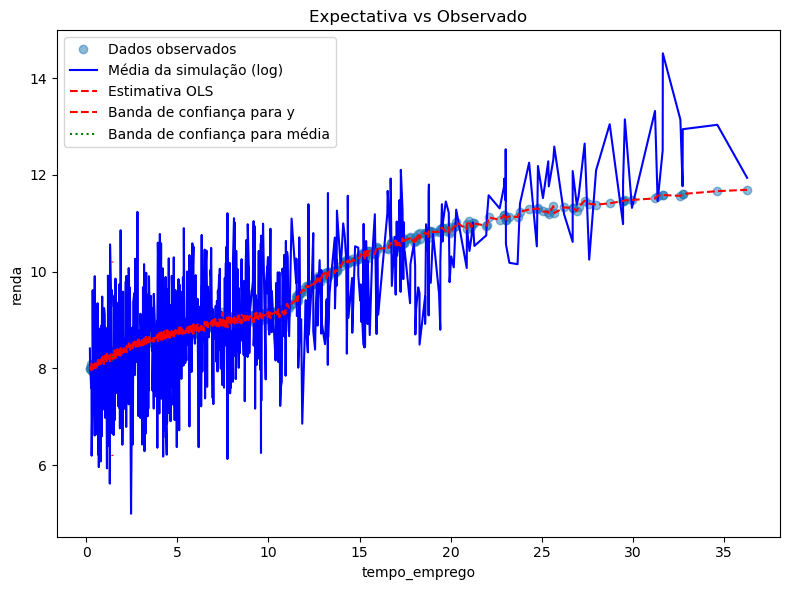

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     I(np.log(renda + 1))   R-squared:                       0.368
Model:                              OLS   Adj. R-squared:                  0.368
Method:                   Least Squares   F-statistic:                     1746.
Date:                  Sun, 20 Jul 2025   Prob (F-statistic):               0.00
Time:                          23:28:34   Log-Likelihood:                -25879.
No. Observations:                 18000   AIC:                         5.177e+04
Df Residuals:                     17993   BIC:                         5.183e+04
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               5.4848      0.299     18.316      0.000       4.898       6.072
I(np.log(X1_1 + 2))     0.6615      0.018     36.327      0.000       0.626       0.697
I(np.log(X1_2 + 2))     0.9997      0.015     67.080      0.000       0.971       1.029
I(np.log(X2_1 + 2))    -0.0069      0.033     -0.208      0.835      -0.072       0.059
I(np.log(X2_2 + 2))     0.4112      0.312      1.317      0.188      -0.201       1.023
I(np.log(X3_1 + 2))     0.3000      0.060      5.028      0.000       0.183       0.417
I(np.log(X3_2 + 2))    -0.0840      0.012     -7.096      0.000      -0.107      -0.061
==============================================================================
Omnibus:                       80.209   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.939
Skew:                          -0.028   Prob(JB):                     9.65e-14
Kurtosis:                       2.723   Cond. No.                         253.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [82]:
y_pred = res_segmentada.predict(df_resid_check[['X1_1', 'X1_2', 'X2_1', 'X2_2', 'X3_1', 'X3_2']])

print(f'R-quadrado: {res_segmentada.rsquared:.2%}')
esp_vs_obs(data=df_resid_check, res=res_segmentada, X='tempo_emprego', y_true='renda', y_pred = y_pred, transformar=True, amostragem=True);
res_segmentada.summary()

<Axes: ylabel='renda'>

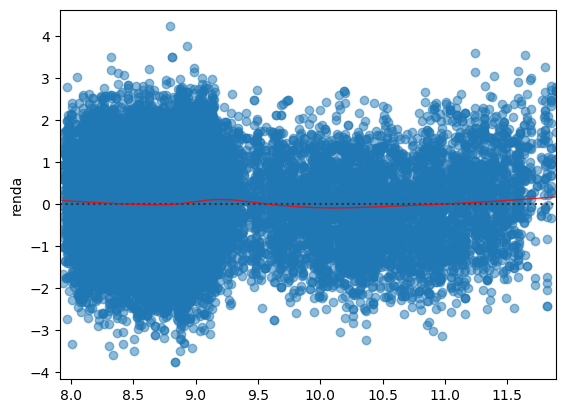

In [83]:
sns.residplot(
    x=y_pred,
    y=np.log(df_resid_check['renda'] + 1),
    data=df_resid_check,
    lowess=True,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "lw": 1, "alpha": 0.8},
)

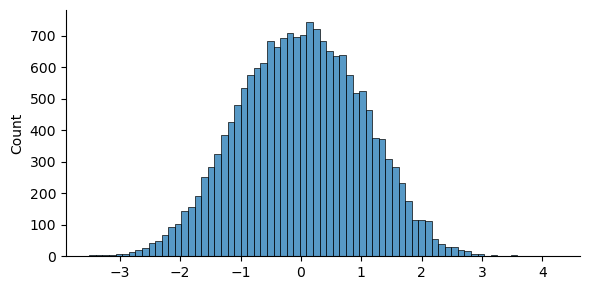

In [84]:
sns.displot(res_segmentada.resid, height=3, aspect=2);

## Outliers

Avalie os *studentized residuals*, verifique se há pontos que parecem ser discrepantes.

Avalie se há pontos influentes.

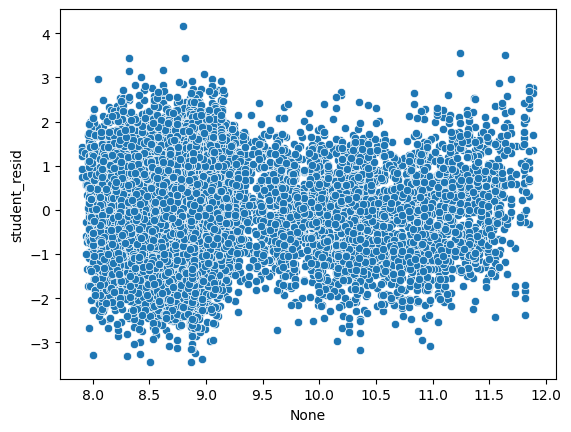

In [85]:
st_res = res_segmentada.outlier_test()
sns.scatterplot(x = y_pred, y = st_res.student_resid);

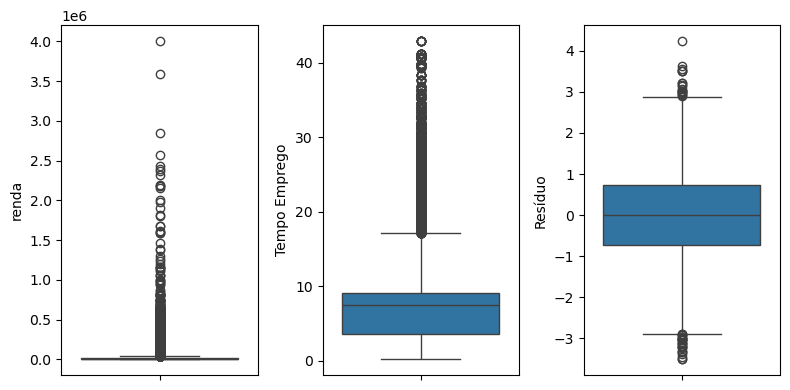

In [86]:
fig, ax = plt.subplots(1,3, figsize=(8,4))


sns.boxplot(y='renda', data=df_resid_check, ax=ax[0])
sns.boxplot(y='tempo_emprego', data=df_resid_check, ax=ax[1])
sns.boxplot(y=res_segmentada.resid, data=df_resid_check, ax=ax[2])

ax[0].set_ylabel('renda')
ax[1].set_ylabel('Tempo Emprego')
ax[2].set_ylabel('Resíduo');

plt.tight_layout()

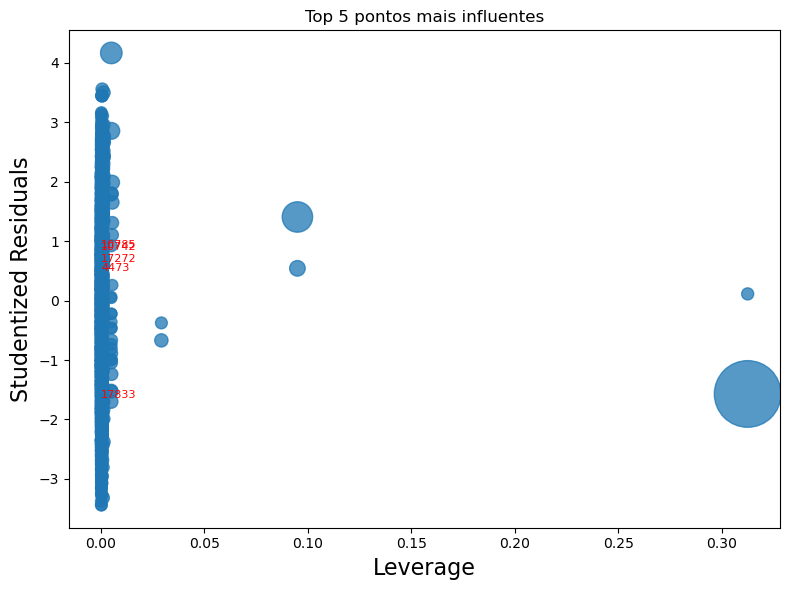

,dfb_Intercept,dfb_I(np.log(X1_1 + 2)),dfb_I(np.log(X1_2 + 2)),dfb_I(np.log(X2_1 + 2)),dfb_I(np.log(X2_2 + 2)),dfb_I(np.log(X3_1 + 2)),dfb_I(np.log(X3_2 + 2)),cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
17833,0.758382,0.003673,0.002904,0.056129,-1.057263,-0.000108,0.006383,0.160165,-1.570613,0.312475,-1.058846,-1.570677,-1.058889
17272,-0.325776,-0.000277,-0.002214,-0.010772,0.454143,-0.001490,-0.004690,0.029689,1.407396,0.094958,0.455877,1.407434,0.455889
10742,-0.184080,0.003046,-0.002084,0.073151,0.273942,-0.029888,0.027994,0.012579,4.165997,0.005048,0.296740,4.167892,0.296875
4473,-0.126160,0.002087,-0.001428,0.050135,0.187748,-0.020484,0.019186,0.005912,2.855915,0.005048,0.203424,2.856484,0.203465
10785,-0.125721,-0.000107,-0.000855,-0.004157,0.175260,-0.000575,-0.001810,0.004422,0.543158,0.094958,0.175937,0.543148,0.175934


In [87]:
influence = res_segmentada.get_influence()
summary_inf = influence.summary_frame()

# Define critérios
outlier_condition = (
    (np.abs(summary_inf["student_resid"]) > 3) |
    (summary_inf["cooks_d"] > 4 / len(df_treino))
)

# Descobre os valores "extremos"
df_outliers = X_train_.join(y_test_)[outlier_condition]

# Calcula influência
influence = res_segmentada.get_influence()
summary_frame = influence.summary_frame()
top_points = summary_frame.sort_values("cooks_d", ascending=False).head(5)

# Plot básico
fig, ax = plt.subplots(figsize=(8, 6))
influence_plot(res_segmentada, ax=ax, criterion="cooks", alpha=0.5, labels=None)

for text in ax.texts:
    text.set_visible(False)

# Adiciona apenas os 5 pontos mais influentes
for i in top_points.index:
    x = influence.hat_matrix_diag[i]
    y = influence.resid_studentized_external[i]
    ax.annotate(i, (x, y), fontsize=8, color='red')

plt.title("Top 5 pontos mais influentes")
plt.tight_layout()
plt.show()

top_points


## Multicolinearidade

Avalie se há questões relacionadas a multicolinearidade através de pelo menos:

- Matriz de correlação de Spearman
- VIF

In [88]:
# Obtém a lista de todas as colunas do DataFrame df
variaveis = previsao_renda.columns.to_list()

# Remove as colunas 'data_ref' e 'index' da lista de variáveis, pois não serão usadas nas análises
variaveis = [x for x in variaveis if x not in ['data_ref', 'index']]

# Calcula a matriz de correlação de Spearman apenas para as variáveis numéricas do dataframe 'df'
correlacao_spearmen = previsao_renda[variaveis].select_dtypes(include=['float64', 'int64']).corr(method='spearman')

# Substitui os valores da diagonal principal por NaN para facilitar a visualização (evita destacar a correlação perfeita de uma variável consigo mesma)
np.fill_diagonal(correlacao_spearmen.values, np.nan)
        
# Aplica o destaque (highlight) ao maior valor de cada linha da matriz de correlação de Spearman,
# usando a cor preta para facilitar a visualização dos pares de variáveis com maior correlação em cada linha.
correlacao_spearmen.style.highlight_max(axis=1, color='black')

,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda
qtd_filhos,nan,-0.415151,-0.089260,0.828600,-0.019957
idade,-0.415151,nan,0.300547,-0.350006,0.107999
tempo_emprego,-0.089260,0.300547,nan,-0.058139,0.501354
qt_pessoas_residencia,0.828600,-0.350006,-0.058139,nan,-0.008260
renda,-0.019957,0.107999,0.501354,-0.008260,nan


In [89]:
previsao_renda_dummies_numericas = pd.get_dummies(
    data=previsao_renda[variaveis], drop_first=True, dtype=int
)

# Renomeia as colunas do DataFrame aplicando a função de padronização de nomes
previsao_renda_dummies_numericas = previsao_renda_dummies_numericas.rename(columns=padronizar_nome)

# Cria uma lista com todas as variáveis independentes, exceto 'renda'
variaveis_independentes = [var for var in previsao_renda_dummies_numericas.columns.to_list() if var != 'renda']

# Monta a string da fórmula para o modelo de regressão linear
formula = "renda ~ " + " + ".join(variaveis_independentes)

# Ajusta o modelo de regressão linear com a fórmula e os dados
r1 = smf.ols(
    formula,
    data=previsao_renda_dummies_numericas
).fit()

# Aplica a função vif_filter para remover variáveis com VIF acima de 5, retornando o dataframe ajustado, as variáveis removidas e o dataframe com os VIFs finais
previsao_renda_vif_ajustado, variaveis_removidas, vif_frame = vif_filter(previsao_renda_dummies_numericas.drop(columns=['renda']), 5)

# Monta a fórmula para o modelo de regressão linear usando apenas as variáveis remanescentes após o filtro de VIF
formula = "I(np.log(renda + 1)) ~ " + " + ".join(vif_frame.feature)

# Ajusta o modelo de regressão linear com a nova fórmula e os dados originais (com dummies)
r2 = smf.ols(
    formula,
    data=previsao_renda_dummies_numericas
).fit()

print(f'R-Quadrado do modelo com variáveis contendo multicolinearidade {round(r1.rsquared_adj, 3)}')
print(f'R-Quadrado do modelo com variáveis livres de multicolinearidade {round(r2.rsquared_adj, 3)}')

R-Quadrado do modelo com variáveis contendo multicolinearidade 0.218
R-Quadrado do modelo com variáveis livres de multicolinearidade 0.393


In [90]:
vif_frame

,feature,VIF
2,idade,2.157455
9,tipo_renda_Pensionista,1.824183
4,sexo_M,1.225969
1,qtd_filhos,1.206025
5,posse_de_veiculo_S,1.199153
3,tempo_emprego,1.155697
8,tipo_renda_Empresario,1.137339
10,tipo_renda_Servidor_publico,1.100820
17,estado_civil_Viuvo,1.091092
15,estado_civil_Solteiro,1.081679


## Ajustes

Faça os ajustes que julgar necessários no modelo e compare as métricas de desempenho do modelo original e ajustado na base de testes.

Regressão com variáveis dummies

In [91]:
formula = 'I(np.log(renda + 1)) ~ C(sexo) + C(posse_de_veiculo) + C(qtd_filhos) + C(tipo_renda) + C(estado_civil) + I(np.log( X1_1 + 2)) + I(np.log(X1_2+ 2)) + I(np.log(X3_1+ 2)) + I(np.log(X3_2+ 2))'

In [92]:
# Ajusta o modelo de regressão linear segmentado usando as transformações logarítmicas das variáveis segmentadas
reg_final = smf.ols(formula, data=X_train_.join(y_train_)).fit() 
reg_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     I(np.log(renda + 1))   R-squared:                       0.378
Model:                              OLS   Adj. R-squared:                  0.377
Method:                   Least Squares   F-statistic:                     519.5
Date:                  Sun, 20 Jul 2025   Prob (F-statistic):               0.00
Time:                          23:36:04   Log-Likelihood:                -25740.
No. Observations:                 18000   AIC:                         5.152e+04
Df Residuals:                     17978   BIC:                         5.170e+04
Df Model:                            21                                         
Covariance Type:              nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             5.5253      0.213     25.889      0.000       5.107       5.944
C(sexo)[T.M]                          0.1180      0.018      6.664      0.000       0.083       0.153
C(posse_de_veiculo)[T.S]              0.0031      0.017      0.182      0.856      -0.030       0.036
C(qtd_filhos)[T.1]                    0.0309      0.021      1.484      0.138      -0.010       0.072
C(qtd_filhos)[T.2]                    0.0021      0.028      0.073      0.942      -0.053       0.058
C(qtd_filhos)[T.3]                   -0.1298      0.069     -1.884      0.060      -0.265       0.005
C(qtd_filhos)[T.4]                    0.2060      0.192      1.075      0.283      -0.170       0.582
C(qtd_filhos)[T.5]                   -0.3246      0.716     -0.453      0.650      -1.728       1.078
C(qtd_filhos)[T.7]                    1.4733      0.716      2.059      0.040       0.071       2.876
C(qtd_filhos)[T.14]                   0.0137      0.716      0.019      0.985      -1.390       1.418
C(tipo_renda)[T.Bolsista]            -0.6894      0.453     -1.522      0.128      -1.577       0.199
C(tipo_renda)[T.Empresário]           0.1643      0.019      8.641      0.000       0.127       0.202
C(tipo_renda)[T.Pensionista]         -0.2534      0.031     -8.266      0.000      -0.313      -0.193
C(tipo_renda)[T.Servidor público]     0.1560      0.028      5.552      0.000       0.101       0.211
C(estado_civil)[T.Separado]           0.0189      0.034      0.564      0.573      -0.047       0.085
C(estado_civil)[T.Solteiro]           0.0104      0.025      0.422      0.673      -0.038       0.059
C(estado_civil)[T.União]             -0.0451      0.029     -1.574      0.115      -0.101       0.011
C(estado_civil)[T.Viúvo]             -0.0509      0.039     -1.318      0.188      -0.127       0.025
I(np.log(X1_1 + 2))                   0.7157      0.019     38.147      0.000       0.679       0.752
I(np.log(X1_2 + 2))                   0.9418      0.016     58.721      0.000       0.910       0.973
I(np.log(X3_1 + 2))                   0.2965      0.060      4.924      0.000       0.179       0.415
I(np.log(X3_2 + 2))                   0.0200      0.015      1.355      0.175      -0.009       0.049
==============================================================================
Omnibus:                       86.280   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               64.020
Skew:                          -0.032   Prob(JB):                     1.25e-14
Kurtosis:                       2.715   Cond. No.                         450.
==============================================================================

Notes:
[1] Standard Errors assume th

In [ ]:
def performance_de_teste(_y_test, _y_pred, _modelo):
    # Cálculo de R-Quadrado (coeficiente de determinação) na base de teste
    _tss_test = ((_y_test - _y_test.mean()) ** 2).sum()  # Soma dos quadrados totais
    _rss_test = ((_y_test - _y_pred) ** 2).sum()         # Soma dos quadrados dos resíduos
    _r_quadrado_test = 1 - _rss_test / _tss_test         # R²: proporção da variância explicada pelo modelo

    # Cálculo de R-Quadrado Ajustado na base de teste
    _qtd_variaveis_explicativas = len(_modelo.params) - 1  # Número de variáveis explicativas (exclui o intercepto)
    _r_quadrado_ajustado_teste = 1 - (1 - _r_quadrado_test) * (len(_y_test) - 1) / (
        len(_y_test) - _qtd_variaveis_explicativas - 1
    )

    # Exibe os resultados formatados
    print(f'R-quadrado: {_r_quadrado_test:.2%}')
    print(f'R-quadrado Ajustado: {_r_quadrado_ajustado_teste:.2%}')
    return _r_quadrado_test, _r_quadrado_ajustado_teste  # Retorna os valores para uso posterior

In [113]:
performance_reg_final = performance_de_teste(y_test_, reg_final.predict(X_test_), reg_final)

R-quadrado: -7.34%
R-quadrado Ajustado: -7.53%


In [114]:
performance_res_segmentada =performance_de_teste(y_test_, res_segmentada.predict(X_test_), res_segmentada)

R-quadrado: -7.34%
R-quadrado Ajustado: -7.40%


R-quadrado: -7.34%
R-quadrado Ajustado: -7.40%


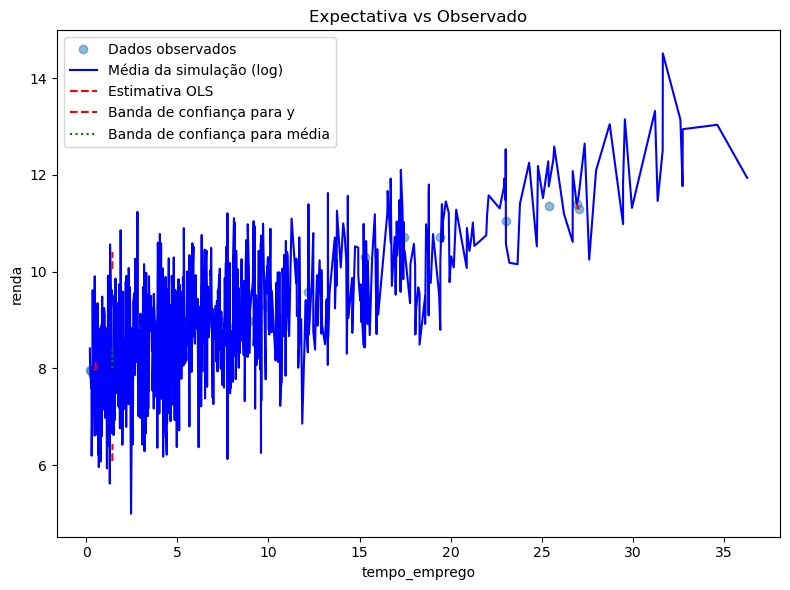

In [97]:
print(f'R-quadrado: {r_quadrado_test:.2%}')
print(f'R-quadrado Ajustado: {r_quadrado_ajustado_teste:.2%}')
esp_vs_obs(data=df_resid_check, res=reg_final, X='tempo_emprego', y_true='renda', y_pred = reg_final.predict(X_test_), transformar=True, amostragem=True);

Regressão apenas com as variáveis numéricas

R-quadrado: -7.34%
R-quadrado Ajustado: -7.40%


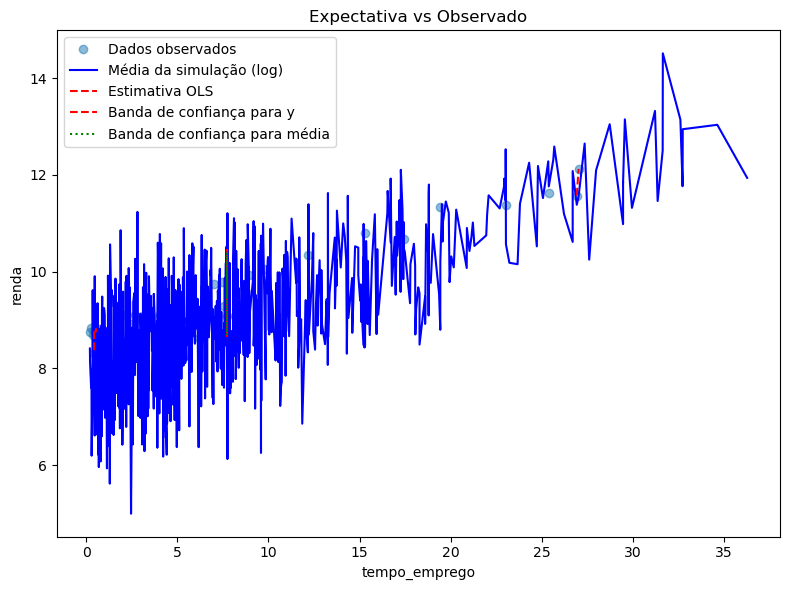

c:\Users\hfasa\anaconda3\envs\EBAC\Lib\site-packages\scipy\stats\_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     I(np.log(renda + 1))   R-squared:                       0.999
Model:                              OLS   Adj. R-squared:                  0.999
Method:                   Least Squares   F-statistic:                     3647.
Date:                  Sun, 20 Jul 2025   Prob (F-statistic):           1.19e-18
Time:                          23:41:18   Log-Likelihood:                 43.209
No. Observations:                    18   AIC:                            -74.42
Df Residuals:                        12   BIC:                            -69.08
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.2941      0.336     27.624      0.000       8.561      10.027
X1_1           0.1313      0.003     37.594      0.000       0.124       0.139
X1_2           0.1512      0.007     22.930      0.000       0.137       0.166
X2_1        7.617e-16   6.66e-16      1.145      0.275   -6.88e-16    2.21e-15
X2_2          -0.1218      0.160     -0.759      0.462      -0.471       0.228
X3_1          -0.0166      0.009     -1.898      0.082      -0.036       0.002
X3_2          -0.0487      0.130     -0.375      0.714      -0.331       0.234
==============================================================================
Omnibus:                        1.086   Durbin-Watson:                   1.950
Prob(Omnibus):                  0.581   Jarque-Bera (JB):                0.759
Skew:                          -0.478   Prob(JB):                        0.684
Kurtosis:                       2.689   Cond. No.                     3.60e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 2.51e-33. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [116]:
performance_res_segmentada = performance_de_teste(y_test_, res_segmentada.predict(X_test_), res_segmentada)
esp_vs_obs(data=df_resid_check, res=res_segmentada, X='tempo_emprego', y_true='renda', y_pred = res_segmentada.predict(X_test_), transformar=True, amostragem=True);
res_segmentada.summary()

In [99]:
X_train_clean = X_train_[['X1_1', 'X1_2', 'X2_1', 'X2_2', 'X3_1', 'X3_2']]

results = stepwise_selection(X_train_clean, y_train_)

print('\nVariáveis selecionadas:')
print(results)

Add  X1_2                           with p-value 0.0
Add  X3_2                           with p-value 0.000117901
Add  X1_1                           with p-value 1.52072e-06
Add  X3_1                           with p-value 0.00132714

Variáveis selecionadas:
['X1_2', 'X3_2', 'X1_1', 'X3_1']


In [100]:
# Ajusta o modelo de regressão linear segmentado usando as transformações logarítmicas das variáveis segmentadas
res_segmentada = smf.ols('I(np.log(renda+1)) ~ I(np.log(X1_1 + 2)) + I(np.log(X1_2 + 2)) + I(np.log(X3_1 + 2))  + I(np.log(X3_2 + 2))', data=X_train_.join(y_train_)).fit() 
res_segmentada.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     I(np.log(renda + 1))   R-squared:                       0.368
Model:                              OLS   Adj. R-squared:                  0.368
Method:                   Least Squares   F-statistic:                     2618.
Date:                  Sun, 20 Jul 2025   Prob (F-statistic):               0.00
Time:                          23:36:05   Log-Likelihood:                -25880.
No. Observations:                 18000   AIC:                         5.177e+04
Df Residuals:                     17995   BIC:                         5.181e+04
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               5.7585      0.209     27.540      0.000       5.349       6.168
I(np.log(X1_1 + 2))     0.6614      0.018     36.348      0.000       0.626       0.697
I(np.log(X1_2 + 2))     0.9997      0.015     67.137      0.000       0.971       1.029
I(np.log(X3_1 + 2))     0.3014      0.060      5.056      0.000       0.185       0.418
I(np.log(X3_2 + 2))    -0.0835      0.011     -7.456      0.000      -0.105      -0.062
==============================================================================
Omnibus:                       78.940   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.121
Skew:                          -0.027   Prob(JB):                     1.45e-13
Kurtosis:                       2.725   Cond. No.                         134.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

R-quadrado: -7.34%
R-quadrado Ajustado: -7.40%


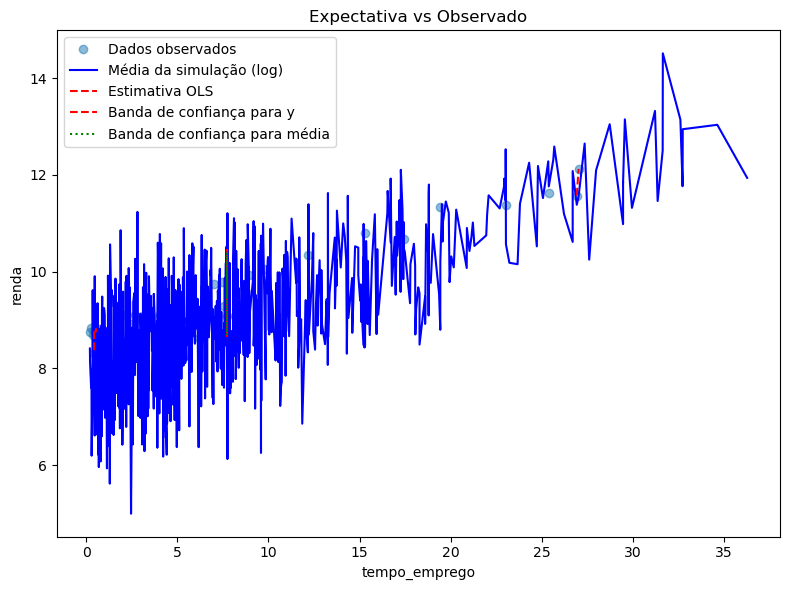

c:\Users\hfasa\anaconda3\envs\EBAC\Lib\site-packages\scipy\stats\_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     I(np.log(renda + 1))   R-squared:                       0.999
Model:                              OLS   Adj. R-squared:                  0.999
Method:                   Least Squares   F-statistic:                     3647.
Date:                  Mon, 21 Jul 2025   Prob (F-statistic):           1.19e-18
Time:                          00:03:16   Log-Likelihood:                 43.209
No. Observations:                    18   AIC:                            -74.42
Df Residuals:                        12   BIC:                            -69.08
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.2941      0.336     27.624      0.000       8.561      10.027
X1_1           0.1313      0.003     37.594      0.000       0.124       0.139
X1_2           0.1512      0.007     22.930      0.000       0.137       0.166
X2_1        7.617e-16   6.66e-16      1.145      0.275   -6.88e-16    2.21e-15
X2_2          -0.1218      0.160     -0.759      0.462      -0.471       0.228
X3_1          -0.0166      0.009     -1.898      0.082      -0.036       0.002
X3_2          -0.0487      0.130     -0.375      0.714      -0.331       0.234
==============================================================================
Omnibus:                        1.086   Durbin-Watson:                   1.950
Prob(Omnibus):                  0.581   Jarque-Bera (JB):                0.759
Skew:                          -0.478   Prob(JB):                        0.684
Kurtosis:                       2.689   Cond. No.                     3.60e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 2.51e-33. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [117]:
performance_res_segmentada = performance_de_teste(y_test_, res_segmentada.predict(X_test_[['X1_1', 'X1_2', 'X2_1', 'X2_2', 'X3_1', 'X3_2']]), res_segmentada)
esp_vs_obs(data=df_resid_check, res=res_segmentada, X='tempo_emprego', y_true='renda', y_pred = res_segmentada.predict(X_test_), transformar=True, amostragem=True);
res_segmentada.summary()

### Modelo feito por agrupamento

#### Criação de conjunto de dados com agrupameto

In [103]:
# Cria categorias (quantis) para a variável tempo_emprego, dividindo em 20 grupos aproximadamente iguais
grupos = pd.qcut(df_treino.tempo_emprego, 20, duplicates='drop')

# Cria uma cópia do dataframe df apenas com as colunas selecionadas em 'variaveis'
tab = df_treino[variaveis].copy()

# Seleciona apenas as colunas numéricas do dataframe
tab = tab.select_dtypes(include=['float64', 'int64'])

# Agrupa o dataframe pelas categorias de tempo_emprego e calcula a média de cada coluna numérica para cada grupo
tab = tab.groupby(grupos).mean()

C:\Users\hfasa\AppData\Local\Temp\ipykernel_25816\3774250945.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = tab.groupby(grupos).mean()


In [104]:
# Definir pontos de corte para testar
C1_values = np.linspace(start=previsao_renda['tempo_emprego'].min(),
                       stop=previsao_renda['tempo_emprego'].max(),
                       num=5)  # Reduzindo para 5 pontos para cada variável

C2_values = np.linspace(start=previsao_renda['qtd_filhos'].min(),
                       stop=previsao_renda['qtd_filhos'].max(),
                       num=5)

C3_values = np.linspace(start=previsao_renda['idade'].min(),
                       stop=previsao_renda['idade'].max(),
                       num=5)

# Lista para armazenar resultados
resultados = []

# Testar combinações de pontos de corte
for c1 in C1_values:
    # Criar segmentos para tempo_emprego
    tab['X1_1'] = np.where(tab['tempo_emprego'] <= c1, 
                                     tab['tempo_emprego'], c1)
    tab['X1_2'] = np.where(tab['tempo_emprego'] > c1, 
                                     tab['tempo_emprego'] - c1, 0)
    
    for c2 in C2_values:
        # Criar segmentos para qtd_filhos
        tab['X2_1'] = np.where(tab['qtd_filhos'] <= c2, 
                                         tab['qtd_filhos'], c2)
        tab['X2_2'] = np.where(tab['qtd_filhos'] > c2, 
                                         tab['qtd_filhos'] - c2, 0)
        
        for c3 in C3_values:
            # Criar segmentos para idade
            tab['X3_1'] = np.where(tab['idade'] <= c3, 
                                            tab['idade'], c3)
            tab['X3_2'] = np.where(tab['idade'] > c3, 
                                            tab['idade'] - c3, 0)
            
            # Ajustar modelo
            formula = 'I(np.log(renda+1)) ~ I(np.log(X1_1 + 10)) + I(np.log(X1_2 + 10)) + X2_1 + X2_2 + I(np.log(X3_1 + 10)) + I(np.log(X3_2 + 10))'
            try:
                modelo = smf.ols(formula, data=tab).fit()
                
                # Armazenar resultados
                resultados.append({
                    'corte_tempo_emprego': c1,
                    'corte_qtd_filhos': c2,
                    'corte_idade': c3,
                    'R2': modelo.rsquared,
                    'AIC': modelo.aic,
                    'BIC': modelo.bic
                })
            except:
                continue

# Converter para DataFrame
df_resultados = pd.DataFrame(resultados)

# Mostrar melhores combinações
df_resultados.sort_values('R2', ascending=False).head(10)

,corte_tempo_emprego,corte_qtd_filhos,corte_idade,R2,AIC,BIC
28,10.815068,0.0,56.5,0.996927,-46.666744,-41.324513
43,10.815068,10.5,56.5,0.996927,-46.666744,-41.324513
33,10.815068,3.5,56.5,0.996927,-46.666744,-41.324513
38,10.815068,7.0,56.5,0.996927,-46.666744,-41.324513
48,10.815068,14.0,56.5,0.996927,-46.666744,-41.324513
27,10.815068,0.0,45.0,0.995730,-40.747835,-35.405604
32,10.815068,3.5,45.0,0.995730,-40.747835,-35.405604
42,10.815068,10.5,45.0,0.995730,-40.747835,-35.405604
37,10.815068,7.0,45.0,0.995730,-40.747835,-35.405604
47,10.815068,14.0,45.0,0.995730,-40.747835,-35.405604


In [105]:
C1 = 10.815068
C2 =  0.0
C3 = 56.5


### CRIANDO DOIS SEGMENTOS PARA A VARIÁVEL TEMPO_EMPREGO
# Cria a variável segmentada X1_1: igual a X1 se X1 <= C1, senão igual a C1
tab['X1_1'] = (tab['tempo_emprego'] <= C1) * tab['tempo_emprego'] + (tab['tempo_emprego'] > C1) * C1

# Cria a variável segmentada X1_2: igual a X1 - C1 se X1 > C1, senão zero
tab['X1_2'] = (tab['tempo_emprego'] > C1) * (tab['tempo_emprego'] - C1)


### CRIANDO DOIS SEGMENTOS PARA QTD_FILHOS
# Cria a variável segmentada X2_1: igual a qtd_filhos se qtd_filhos <= C2, senão igual a C2
tab['X2_1'] = (tab['qtd_filhos'] <= C2) * tab['qtd_filhos'] + (tab['qtd_filhos'] > C2) * C2

# Cria a variável segmentada X1_2: igual a qtd_filhos - C2 se X1 > C2, senão zero
tab['X2_2'] = (tab['qtd_filhos'] > C2) * (tab['qtd_filhos'] - C2)


### CRIANDO DOIS SEGMENTOS PARA A VARIÁVEL IDADE
# Cria a variável segmentada X3_1: igual a idade se idade <= C3, senão igual a C3
tab['X3_1'] = (tab['idade'] <= C3) * tab['idade'] + (tab['idade'] > C3) * C3

# Cria a variável segmentada X1_2: igual a X1 - C3 se X1 > C3, senão zero
tab['X3_2'] = (tab['idade'] > C3) * (tab['idade'] - C3)

res_segmentada = smf.ols(' I(np.log(renda + 1)) ~ X1_1 + X1_2 + X2_1 + X2_2 + X3_1 + X3_2', data=tab).fit()
res_segmentada.summary()

c:\Users\hfasa\anaconda3\envs\EBAC\Lib\site-packages\scipy\stats\_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     I(np.log(renda + 1))   R-squared:                       0.999
Model:                              OLS   Adj. R-squared:                  0.999
Method:                   Least Squares   F-statistic:                     3647.
Date:                  Sun, 20 Jul 2025   Prob (F-statistic):           1.19e-18
Time:                          23:36:07   Log-Likelihood:                 43.209
No. Observations:                    18   AIC:                            -74.42
Df Residuals:                        12   BIC:                            -69.08
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.2941      0.336     27.624      0.000       8.561      10.027
X1_1           0.1313      0.003     37.594      0.000       0.124       0.139
X1_2           0.1512      0.007     22.930      0.000       0.137       0.166
X2_1        7.617e-16   6.66e-16      1.145      0.275   -6.88e-16    2.21e-15
X2_2          -0.1218      0.160     -0.759      0.462      -0.471       0.228
X3_1          -0.0166      0.009     -1.898      0.082      -0.036       0.002
X3_2          -0.0487      0.130     -0.375      0.714      -0.331       0.234
==============================================================================
Omnibus:                        1.086   Durbin-Watson:                   1.950
Prob(Omnibus):                  0.581   Jarque-Bera (JB):                0.759
Skew:                          -0.478   Prob(JB):                        0.684
Kurtosis:                       2.689   Cond. No.                     3.60e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 2.51e-33. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [106]:
treino_agrupamento = X_train_.copy().drop(
    columns=[
        "X1_1",
        "X1_2",
        "X2_1",
        "X2_2",
        "X3_1",
        "X3_2",
        'qt_pessoas_residencia',
        'educacao',
        'tipo_residencia'
    ]
)

teste_agrupamento = X_test_.copy().drop(
    columns=[
        "X1_1",
        "X1_2",
        "X2_1",
        "X2_2",
        "X3_1",
        "X3_2",
        'qt_pessoas_residencia',
        'educacao',
        'tipo_residencia'
    ]
)

C1_values = np.linspace(start=treino_agrupamento['tempo_emprego'].min(),
                       stop=treino_agrupamento['tempo_emprego'].max(),
                       num=5)  # Reduzindo para 5 pontos para cada variável

C2_values = np.linspace(start=treino_agrupamento['qtd_filhos'].min(),
                       stop=treino_agrupamento['qtd_filhos'].max(),
                       num=5)

C3_values = np.linspace(start=treino_agrupamento['idade'].min(),
                       stop=treino_agrupamento['idade'].max(),
                       num=5)

C1_values = np.linspace(start=teste_agrupamento['tempo_emprego'].min(),
                       stop=teste_agrupamento['tempo_emprego'].max(),
                       num=5)  # Reduzindo para 5 pontos para cada variável

C2_values = np.linspace(start=teste_agrupamento['qtd_filhos'].min(),
                       stop=teste_agrupamento['qtd_filhos'].max(),
                       num=5)

C3_values = np.linspace(start=teste_agrupamento['idade'].min(),
                       stop=teste_agrupamento['idade'].max(),
                       num=5)

# Testar combinações de pontos de corte
for c1 in C1_values:
    # Criar segmentos para tempo_emprego
    treino_agrupamento['X1_1'] = np.where(treino_agrupamento['tempo_emprego'] <= c1, 
                                     treino_agrupamento['tempo_emprego'], c1)
    treino_agrupamento['X1_2'] = np.where(treino_agrupamento['tempo_emprego'] > c1, 
                                     treino_agrupamento['tempo_emprego'] - c1, 0)
    
    for c2 in C2_values:
        # Criar segmentos para qtd_filhos
        treino_agrupamento['X2_1'] = np.where(treino_agrupamento['qtd_filhos'] <= c2, 
                                         treino_agrupamento['qtd_filhos'], c2)
        treino_agrupamento['X2_2'] = np.where(treino_agrupamento['qtd_filhos'] > c2, 
                                         treino_agrupamento['qtd_filhos'] - c2, 0)
        
        for c3 in C3_values:
            # Criar segmentos para idade
            treino_agrupamento['X3_1'] = np.where(treino_agrupamento['idade'] <= c3, 
                                            treino_agrupamento['idade'], c3)
            treino_agrupamento['X3_2'] = np.where(treino_agrupamento['idade'] > c3, 
                                            treino_agrupamento['idade'] - c3, 0)
            
# Testar combinações de pontos de corte
for c1 in C1_values:
    # Criar segmentos para tempo_emprego
    teste_agrupamento['X1_1'] = np.where(teste_agrupamento['tempo_emprego'] <= c1, 
                                     teste_agrupamento['tempo_emprego'], c1)
    teste_agrupamento['X1_2'] = np.where(teste_agrupamento['tempo_emprego'] > c1, 
                                     teste_agrupamento['tempo_emprego'] - c1, 0)
    
    for c2 in C2_values:
        # Criar segmentos para qtd_filhos
        teste_agrupamento['X2_1'] = np.where(teste_agrupamento['qtd_filhos'] <= c2, 
                                         teste_agrupamento['qtd_filhos'], c2)
        teste_agrupamento['X2_2'] = np.where(teste_agrupamento['qtd_filhos'] > c2, 
                                         teste_agrupamento['qtd_filhos'] - c2, 0)
        
        for c3 in C3_values:
            # Criar segmentos para idade
            teste_agrupamento['X3_1'] = np.where(teste_agrupamento['idade'] <= c3, 
                                            teste_agrupamento['idade'], c3)
            teste_agrupamento['X3_2'] = np.where(teste_agrupamento['idade'] > c3, 
                                            teste_agrupamento['idade'] - c3, 0)
            
treino_agrupamento.drop(columns=['tempo_emprego', 'idade', 'qtd_filhos'], inplace=True)
teste_agrupamento.drop(columns=['tempo_emprego', 'idade', 'qtd_filhos'], inplace=True)

#### Gráfico de resíduos da modelagem por agrupamento

<Axes: ylabel='renda'>

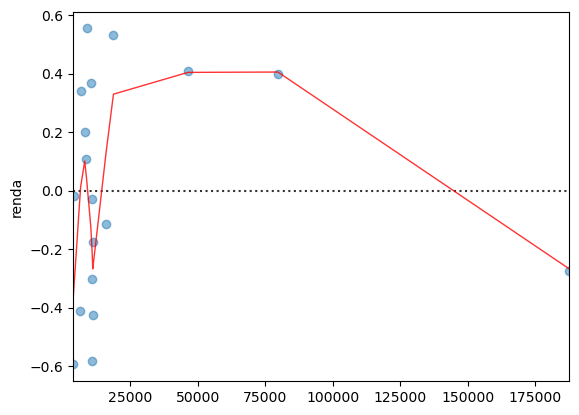

In [107]:
# Seleciona as variáveis independentes, excluindo 'renda', 'index' e 'data_ref'
variaveis_independentes = [var for var in tab.columns.to_list() if var not in ['renda', 'index', 'data_ref','idade', 'tempo_emprego', 'qt_pessoas_residencia']]
# Monta a fórmula para o modelo de regressão linear
formula = 'renda ~' + '+'.join(variaveis_independentes)

# Ajusta o modelo de regressão linear usando o DataFrame de verificação de resíduos
modelo = smf.ols(formula, data=tab).fit()

# Plota o gráfico dos resíduos (diferença entre valores observados e previstos) em relação aos valores previstos
sns.residplot(
    x=modelo.predict(tab[variaveis_independentes]),  # valores previstos pelo modelo
    y=np.log(tab['renda'] + 1),                      # log da renda observada
    data=tab,
    lowess=True,                                                # suavização local
    scatter_kws={"alpha": 0.5},                                 # transparência dos pontos
    line_kws={"color": "red", "lw": 1, "alpha": 0.8},           # estilo da linha de tendência
)

#### Performance em teste da modelagem com agrupamento

In [108]:
# Cálculo de R-Quadrado
tss_test = ((y_test_ - res_segmentada.predict(teste_agrupamento[['X1_1','X1_2','X2_1','X2_2','X3_1','X3_2']]).mean()) ** 2).sum()
rss_test = ((y_test_ - res_segmentada.predict(teste_agrupamento[['X1_1','X1_2','X2_1','X2_2','X3_1','X3_2']])) ** 2).sum()
r_quadrado_test = 1 - rss_test / tss_test

# Cálculo de R-Quadrado Ajustado
qtd_variaveis_explicativas = len(res_segmentada.params) - 1
r_quadrado_ajustado_teste = 1 - (1 - r_quadrado_test) * (len(y_test_) - 1) / (
    len(y_test_) - qtd_variaveis_explicativas - 1
)

R-quadrado: 0.00%
R-quadrado Ajustado: -0.05%


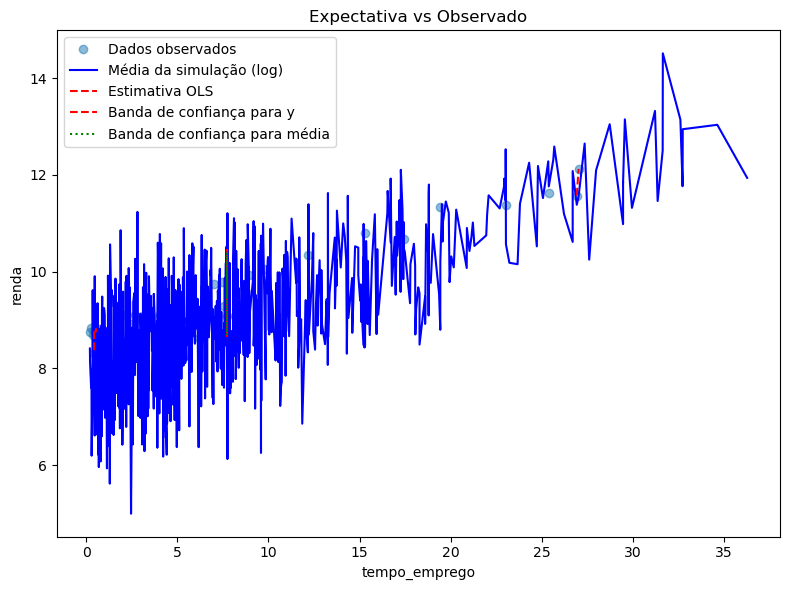

c:\Users\hfasa\anaconda3\envs\EBAC\Lib\site-packages\scipy\stats\_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     I(np.log(renda + 1))   R-squared:                       0.999
Model:                              OLS   Adj. R-squared:                  0.999
Method:                   Least Squares   F-statistic:                     3647.
Date:                  Sun, 20 Jul 2025   Prob (F-statistic):           1.19e-18
Time:                          23:36:08   Log-Likelihood:                 43.209
No. Observations:                    18   AIC:                            -74.42
Df Residuals:                        12   BIC:                            -69.08
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.2941      0.336     27.624      0.000       8.561      10.027
X1_1           0.1313      0.003     37.594      0.000       0.124       0.139
X1_2           0.1512      0.007     22.930      0.000       0.137       0.166
X2_1        7.617e-16   6.66e-16      1.145      0.275   -6.88e-16    2.21e-15
X2_2          -0.1218      0.160     -0.759      0.462      -0.471       0.228
X3_1          -0.0166      0.009     -1.898      0.082      -0.036       0.002
X3_2          -0.0487      0.130     -0.375      0.714      -0.331       0.234
==============================================================================
Omnibus:                        1.086   Durbin-Watson:                   1.950
Prob(Omnibus):                  0.581   Jarque-Bera (JB):                0.759
Skew:                          -0.478   Prob(JB):                        0.684
Kurtosis:                       2.689   Cond. No.                     3.60e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 2.51e-33. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [109]:
print(f'R-quadrado: {r_quadrado_test:.2%}')
print(f'R-quadrado Ajustado: {r_quadrado_ajustado_teste:.2%}')
esp_vs_obs(data=df_resid_check, res=res_segmentada, X='tempo_emprego', y_true='renda', y_pred = res_segmentada.predict(X_test_), transformar=True, amostragem=True);
res_segmentada.summary()